In [ ]:
!pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0



--- Starting Causal Analysis with the new Fitbit Data ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Average Treatment Effect (ATE): 1.209
This means a high-calorie day, on average, changes the next day's resting HR by 1.209 bpm.


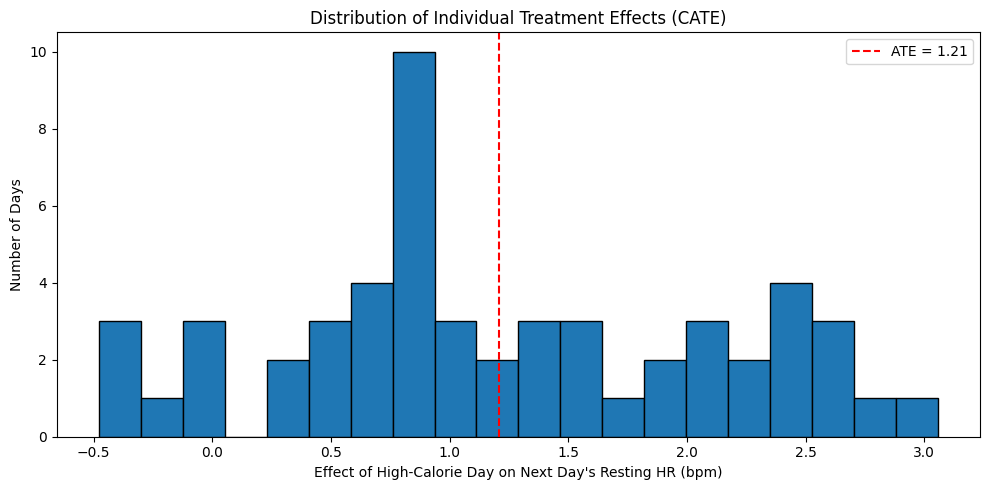

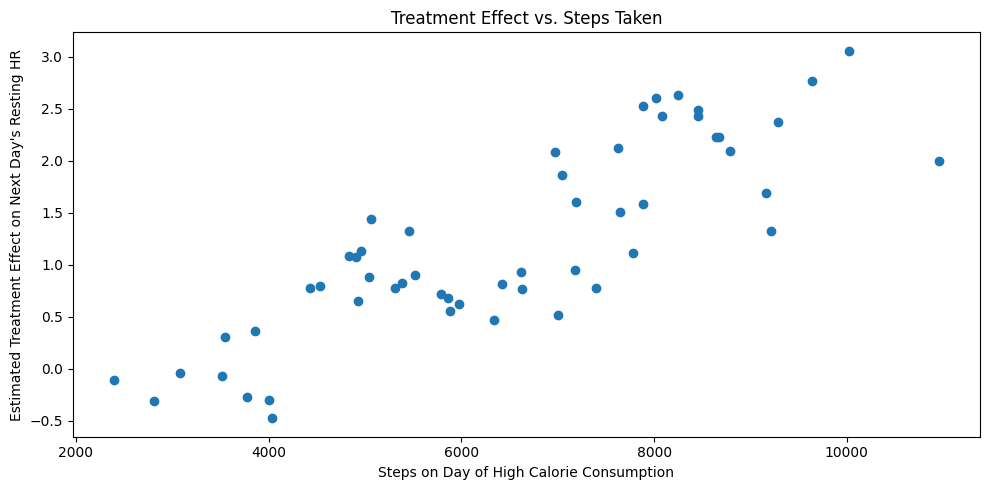

In [ ]:

print("\n--- Starting Causal Analysis with the new Fitbit Data ---")

df = pd.read_csv('fitbit_data.csv')
df['date'] = pd.to_datetime(df['date'])


df['high_calorie_day'] = (df['calories_consumed'] > 2500).astype(int)

df['next_day_resting_hr'] = df['resting_hr'].shift(-1)


df = df.dropna()

outcome = 'next_day_resting_hr'
treatment = 'high_calorie_day'


features = [
    'weight_kg', 'steps', 'active_calories', 'resting_hr', 'hrv',
    'sleep_hours', 'deep_sleep_time', 'spo2', 'respiratory_rate', 'standing_hours'
]

Y = df[outcome]
T = df[treatment]
X = df[features]
W = df[features]

train_size = int(len(df) * 0.7)
Y_train, Y_test = Y.iloc[:train_size], Y.iloc[train_size:]
T_train, T_test = T.iloc[:train_size], T.iloc[train_size:]
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
W_train, W_test = W.iloc[:train_size], W.iloc[train_size:]

outcome_model = XGBRegressor(random_state=42)
effect_model = XGBRegressor(random_state=42)

est = XLearner(models=outcome_model, cate_models=effect_model)
est.fit(Y=Y_train, T=T_train, X=X_train)


individual_treatment_effects = est.effect(X_test)
average_treatment_effect = individual_treatment_effects.mean()

print(f"\nAverage Treatment Effect (ATE): {average_treatment_effect:.3f}")
print(f"This means a high-calorie day, on average, changes the next day's resting HR by {average_treatment_effect:.3f} bpm.")


results_df = X_test.copy()
results_df['individual_effect'] = individual_treatment_effects

plt.figure(figsize=(10, 5))
plt.hist(individual_treatment_effects, bins=20, edgecolor='k')
plt.title("Distribution of Individual Treatment Effects (CATE)")
plt.xlabel("Effect of High-Calorie Day on Next Day's Resting HR (bpm)")
plt.ylabel("Number of Days")
plt.axvline(average_treatment_effect, color='r', linestyle='--', label=f'ATE = {average_treatment_effect:.2f}')
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
plt.scatter(results_df['steps'], results_df['individual_effect'])
plt.title("Treatment Effect vs. Steps Taken")
plt.xlabel("Steps on Day of High Calorie Consumption")
plt.ylabel("Estimated Treatment Effect on Next Day's Resting HR")
plt.tight_layout()
plt.show()